# STAT 207 Homework 6 [25 points]

## Deeper Dive into Hypothesis Testing and Introduction to Linear Regression

Due: Monday, March 23, end of day (11:59 pm CT)

Late submissions accepted until Tuesday, March 24 at noon

<hr>

## Imports 

Run the following code cell to import the necessary packages into the file.  You may import additional packages, as needed for this assignment.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

## Case Study: County Housing Information

The provided **county.csv** file contains various statistics about the population of every county in the United States.  You can read more about this dataset and its variables here:

https://www.openintro.org/data/index.php?data=county

**Unit of Observation**: Each row contains data recorded for a county

**Variables**: 

- In questions 1 and 2, we will focus on the `multi_unit` variable in the data, which reports the percent of housing units in each county that are in multi-unit structures (e.g. apartments).  
- In question 3, we will add the `homeownership` variable, which records the rate of home ownership.  

Below, we read in the data as `df` for later analysis.

In [3]:
df = pd.read_csv('county.csv', na_values = ['data unavailable'])
df

,name,state,pop2000,pop2010,pop2017,pop_change,poverty,homeownership,multi_unit,unemployment_rate,metro,median_edu,per_capita_income,median_hh_income,smoking_ban
0,Autauga County,Alabama,43671.0,54571,55504.0,1.48,13.7,77.5,7.2,3.86,yes,some_college,27841.70,55317.0,none
1,Baldwin County,Alabama,140415.0,182265,212628.0,9.19,11.8,76.7,22.6,3.99,yes,some_college,27779.85,52562.0,none
2,Barbour County,Alabama,29038.0,27457,25270.0,-6.22,27.2,68.0,11.1,5.90,no,hs_diploma,17891.73,33368.0,partial
3,Bibb County,Alabama,20826.0,22915,22668.0,0.73,15.2,82.9,6.6,4.39,yes,hs_diploma,20572.05,43404.0,none
4,Blount County,Alabama,51024.0,57322,58013.0,0.68,15.6,82.0,3.7,4.02,yes,hs_diploma,21367.39,47412.0,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3137,Sweetwater County,Wyoming,37613.0,43806,43534.0,-3.57,12.0,73.7,14.6,4.55,no,some_college,30282.59,71083.0,none
3138,Teton County,Wyoming,18251.0,21294,23265.0,4.21,6.8,60.8,31.9,2.99,no,bachelors,48557.37,80049.0,partial
3139,Uinta County,Wyoming,19742.0,21118,20495.0,-2.22,14.9,73.7,17.0,4.50,no,some_college,27048.12,54672.0,none
3140,Washakie County,Wyoming,8289.0,8533,8064.0,-4.31,12.8,70.9,10.0,4.08,no,some_college,27494.83,51362.0,none


## 1. Learning about the Multi-Unit Housing Rate [1.5 points] 

**a)** Calculate the mean multi-unit housing rate for the data.

In [5]:
df['multi_unit'].mean()

np.float64(12.321896880967534)

**b)** We will start by creating a sampling distribution of the mean multi-unit housing rate for 5 randomly selected counties selected **without replacement**.  Record 5000 repetitions in your simulated sampling distribution.

In [ ]:
sim = []
for i in range(5000):
    sample = df.sample(5,replace=False)
    stat = sample['multi_unit'].mean()
    sim.append(stat)
sim = pd.DataFrame(sim, columns=["Mean Multi_Unit"])
sim

,Mean Multi_Unit
0,9.62
1,8.30
2,15.10
3,9.92
4,15.94
...,...
4995,14.14
4996,21.44
4997,10.66
4998,11.98


**c)** I'd suggest turning to Q1 on Gradescope here.  

I don't anticipate a need to perform any more calculations or analyses for this problem.  This space is available for any optional calculations or analyses that you'd like.

(array([ 282., 1471., 1635.,  988.,  412.,  124.,   58.,   21.,    7.,
           2.]),
 array([ 3.48,  6.88, 10.28, 13.68, 17.08, 20.48, 23.88, 27.28, 30.68,
        34.08, 37.48]),
 <BarContainer object of 10 artists>)

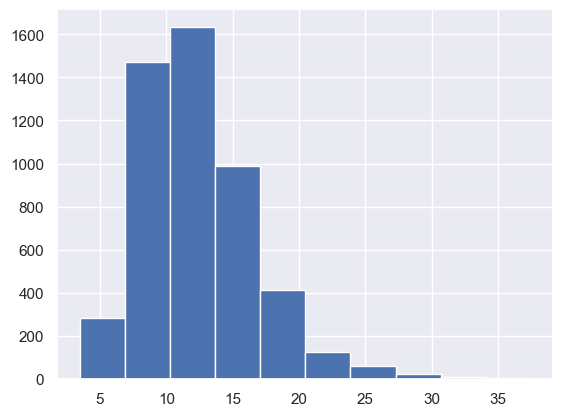

In [11]:
plt.hist(sim)

## 2. Deeper Dive Into p-Values and Significance Levels [2 points]

For this question, we'll take a deeper dive into p-values and significance levels.  The general procedure we'll follow is different from what we typically suggest in class, but there's a reason for this!  In other words, we typically simulate a sampling distribution to calculate a p-value.  In this specific case, we'll use our simulated sampling distribution from part **1b**.  You might take a look at Q2.1 on Gradescope to help motivate why we do this.

**a)** First, take a random sample of size 5 from the population of counties **without replacement**.  Within the `sample` function, use the argument `random_state = 207`.  Using this random sample along with the sampling distribution from part **1b**, calculate the p-value for the hypotheses below:

$H_0: \mu = 12.32$

$H_a: \mu > 12.32$

In [14]:
sample_207 = df.sample(5,replace=False, random_state=207)
sample_mean = sample_207['multi_unit'].mean()
pvalue = (sim['Mean Multi_Unit'] >= sample_mean).mean()
pvalue

np.float64(0.2426)

**b)** Now, we'd like to explore the general behavior of a p-value.  In order to do this, we will generate many repeated random samples of size 5.  For each of these random samples, we will calculate a p-value.  In essence, we will repeat the process from **part 2a** many times, although we will **not** use the `random_state` argument for our repeated samples.

Specifically, you should:
- gather a random sample of size 5 without replacement (which mimics a realistic sampling scheme in this scenario),
- use the sampling distribution from part **1b** to calculate the corresponding p-value, and
- save the p-value for future analysis

Repeat this process 2000 times, so that you have 2000 different p-values in your data to explore.

*Hint:* As a first step, determine the appropriate code to calculate the p-value for a single random sample of size 5.  Then, once you have code that works for a single random sample, generalize it so that you can repeat this for 2000 different samples.

*A second hint:* I know that the procedure described above may feel a little strange.  Similar to **part 2a**, you won't need to generate a sampling distribution at all for this question.

In [15]:
pvals = []

for i in range(2000):
    sample = df.sample(5, replace=False)
    sample_mean = sample['multi_unit'].mean()
    pvalue = (sim['Mean Multi_Unit'] >= sample_mean).mean()
    pvals.append(pvalue)

pvals = pd.DataFrame(pvals, columns=['pvalue'])
pvals

,pvalue
0,0.9242
1,0.7604
2,0.5600
3,0.1368
4,0.9446
...,...
1995,0.6438
1996,0.7576
1997,0.3726
1998,0.9130


**c)** I'd suggest turning to Q2 on Gradescope here.  

You'll likely need to further explore the data for Gradescope Q2.  You can use this section for any exploration that you'd like, although there are no points associated with this part.

(array([158., 238., 191., 197., 210., 190., 196., 195., 236., 189.]),
 array([2.0000e-04, 1.0018e-01, 2.0016e-01, 3.0014e-01, 4.0012e-01,
        5.0010e-01, 6.0008e-01, 7.0006e-01, 8.0004e-01, 9.0002e-01,
        1.0000e+00]),
 <BarContainer object of 10 artists>)

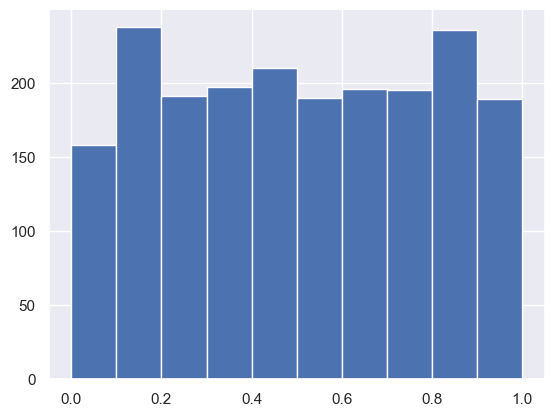

In [16]:
plt.hist(pvals)

In [17]:
(pvals['pvalue'] < 0.05).mean()

np.float64(0.047)

In [19]:
(pvals['pvalue'] < 0.02).mean()

np.float64(0.0165)

## 3. Exploring Champaign and its Neighboring Counties [1 point]

**a)** Suppose that we consider Champaign and its four neighboring counties (Vermilion, Ford, Piatt, and Douglas) as a sample of counties from the US.  First, calculate the sample mean multi-unit rate of these five counties from Illinois.  Then, using your simulated sampling distribution from **1b** and the hypotheses from **2a**, calculate the p-value based on these five counties. 

**Tip**: You may want to review Homework 4.  We can use the **`&`** ("and") operator to indicate that we want **both** conditions on either side of the operator to be met.  We can use the **`|`** ("or") operator to indicate that we want **at least one** of the conditions to be met.  We can also chain these operators together if we need to represent more complex operations.

In [20]:
champaign_sample = df[
    (df['state'] == 'Illinois') &
    (df['name'].isin([
        'Champaign County',
        'Vermilion County',
        'Ford County',
        'Piatt County',
        'Douglas County'
    ]))
]

champaign_mean = champaign_sample['multi_unit'].mean()
pvalue = (sim['Mean Multi_Unit'] >= champaign_mean).mean()

champaign_mean, pvalue

(np.float64(15.260000000000002), np.float64(0.2086))

**b)** I'd suggest turning to Q3 on Gradescope here.

I don't anticipate a need to perform any more calculations or analyses for this problem.  This space is available for any optional calculations or analyses that you'd like.

## 4. Linear Regression [4 points]

How does the rate of homeownership affect the percent of housing units that are in multi-unit structures?

**a)** Generate a visualization to observe the relationship between the rate of homeownership and the percentage of multi-unit structure housing in the county.  Be sure to place each variable on the correct axes based on the underlying question above.

<Axes: xlabel='homeownership', ylabel='multi_unit'>

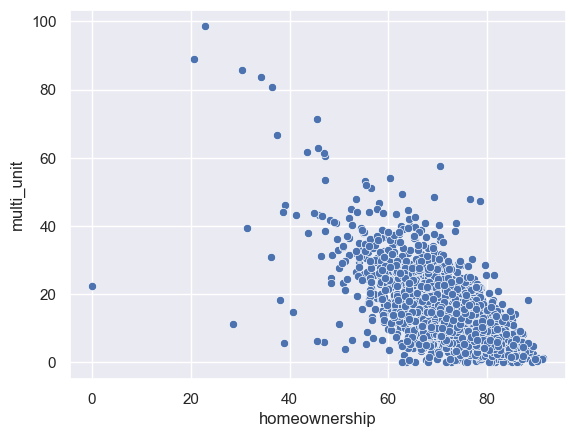

In [27]:
sns.scatterplot(data=df, x= 'homeownership', y ='multi_unit')


**b)** Fit a linear model that predicts the `multi_unit` from `homeownership`.  Print the summary of the model.

In [33]:
from sklearn.linear_model import LinearRegression
X = df[['homeownership']]
y = df['multi_unit']

model = LinearRegression()
model.fit(X, y)
print('slope: ', model.coef_)
print('intercept: ', model.intercept_)
print("R^2:", model.score(X, y))

slope:  [-0.79743071]
intercept:  70.7468176744347
R^2: 0.45193179043305054


**c)** I'd suggest turning to Q4 on Gradescope here.

You may need to perform more calculations or analyses for this problem.  This space is available for any optional calculations or analyses that you'd like, although there are no points associated with this part.

## 5. AI Acknowledgement

Our course policy is that you should write all of your own interpretations and other narrative answers (phrases or sentences) yourself without the assistance of AI.  You may use AI to help guide your code, although you should write all of your own code yourself (not copy-paste from another source) and you should cite your use of AI.  I would encourage you to try to generate any necessary code yourself first using course resources and using AI as a debugging tool if/when you reach an error that you can't figure out or to help you perform any coding tasks that are more advanced than we've demonstrated during class (intended only for projects).  

Did you use AI on this assignment?  Did you use other resources outside of our course-provided resources on this assignment?

No

If you used AI or other resources, answer the following questions to cite your usage.

- Which AI and/or resources did you use (including links, if appropriate)?
- What prompts did you ask it?
- How did you integrate the responses into your assignment?  Specifically, which questions or parts are associated with this usage?

Note: answering these three questions are enough for our course but may not be enough for a different course or context.

N/A

Remember to keep all your cells and hit the save icon above periodically to checkpoint (save) your results on your local computer. Once you are satisified with your results restart the kernel and run all (Kernel -> Restart & Run All). **Make sure nothing has changed**. Checkpoint and exit (File -> Save and Checkpoint + File -> Close and Halt). Follow the instructions on the Homework 6 Canvas Assignment to submit your notebook to GitHub.